In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import (KMeans, SpectralClustering, 
                             AgglomerativeClustering, Birch)
from sklearn.mixture import GaussianMixture
from sklearn.metrics import (silhouette_score, 
                             calinski_harabasz_score, 
                             davies_bouldin_score)

In [4]:
# Görselleştirme ayarları
sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

In [5]:
# Veri setini yükleme
data = pd.read_csv('Wholesale customers data.csv')
numerical_features = ['Fresh', 'Milk', 'Grocery', 'Frozen', 'Detergents_Paper', 'Delicassen']

print("Data Shape:", data.shape)
data.head()

Data Shape: (440, 8)


,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
0,2,3,12669,9656,7561,214,2674,1338
1,2,3,7057,9810,9568,1762,3293,1776
2,2,3,6353,8808,7684,2405,3516,7844
3,1,3,13265,1196,4221,6404,507,1788
4,2,3,22615,5410,7198,3915,1777,5185


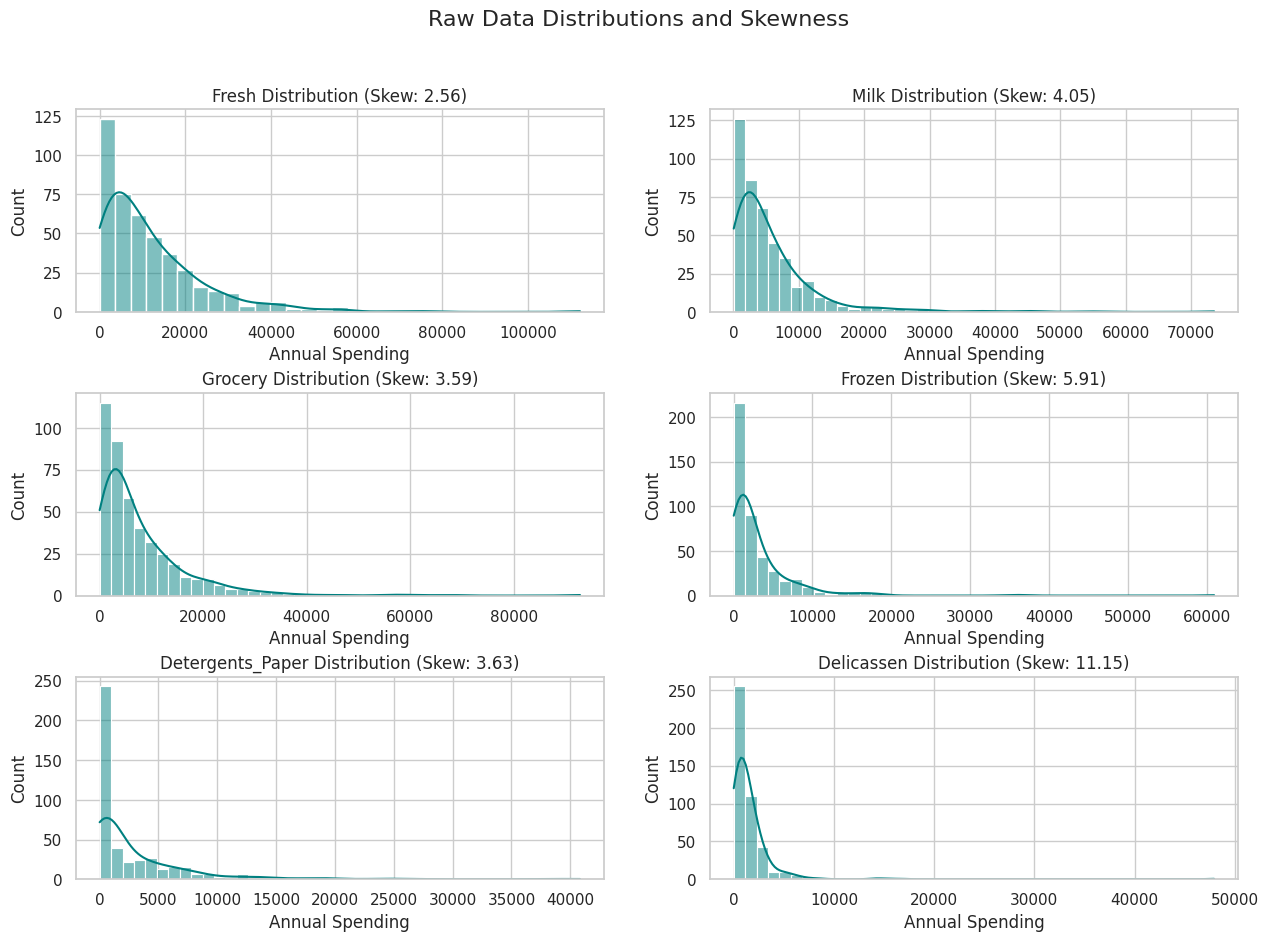

In [8]:
plt.figure(figsize=(15, 10))
plt.subplots_adjust(hspace=0.4)
for i, feature in enumerate(numerical_features):
    ax = plt.subplot(3, 2, i + 1)
    sns.histplot(data[feature], kde=True, color='teal', ax=ax)
    skew_val = data[feature].skew()
    ax.set_title(f"{feature} Distribution (Skew: {skew_val:.2f})")
    ax.set_xlabel("Annual Spending")
plt.suptitle("Raw Data Distributions and Skewness", fontsize=16)
plt.show()

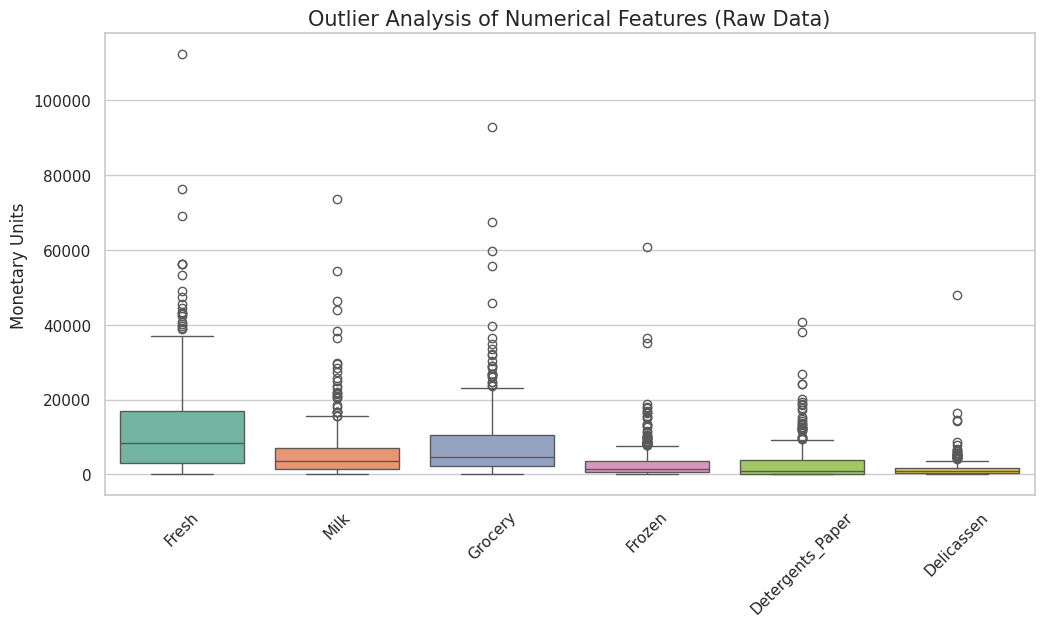

In [10]:
# Outlier analizi
plt.figure(figsize=(12, 6))
sns.boxplot(data=data[numerical_features], palette="Set2")
plt.title("Outlier Analysis of Numerical Features (Raw Data)", fontsize=15)
plt.ylabel("Monetary Units")
plt.xticks(rotation=45)
plt.show()

In [ ]:
# Veri sağa çarpık (skewed) olduğu için log dönüşümü
X_log = np.log1p(data[numerical_features])

# Standardizasyon
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_log)

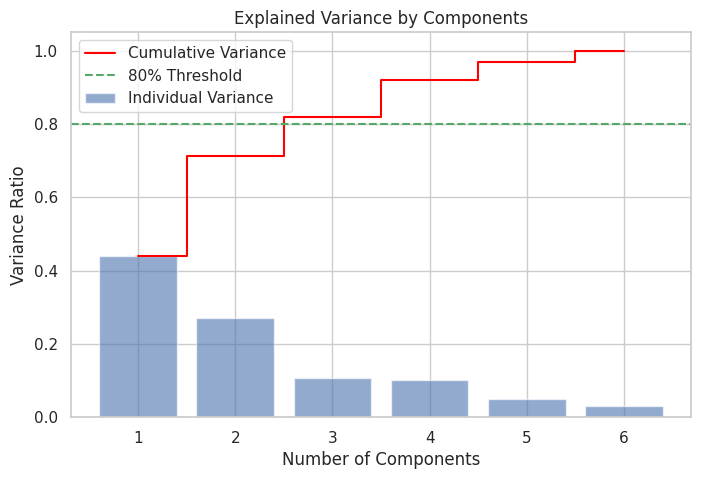

In [ ]:
# PCA varyans analizi
pca_full = PCA()
pca_full.fit(X_scaled)

plt.figure(figsize=(8, 5))
plt.bar(range(1, 7), pca_full.explained_variance_ratio_, alpha=0.6, label='Individual Variance')
plt.step(range(1, 7), np.cumsum(pca_full.explained_variance_ratio_), where='mid', label='Cumulative Variance', color='red')
plt.axhline(y=0.8, color='g', linestyle='--', label='80% Threshold')
plt.title('Explained Variance by Components')
plt.xlabel('Number of Components')
plt.ylabel('Variance Ratio')
plt.legend()
plt.show()

# pca 3 olmalı (%80'i geçtiği için)
pca = PCA(n_components=3)
X_pca = pca.fit_transform(X_scaled)

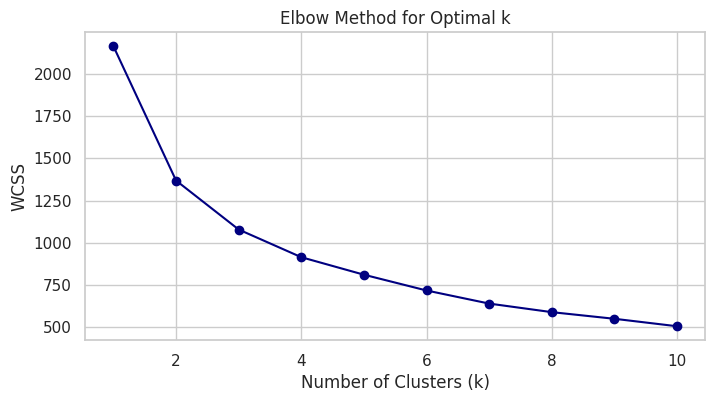

In [ ]:
# İdeal Küme Sayısı Belirlemek için Elbow Method 
wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42, n_init=10)
    kmeans.fit(X_pca)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(range(1, 11), wcss, marker='o', color='navy')
plt.title('Elbow Method for Optimal k')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('WCSS')
plt.show()

Grafikteki "kırılma" (dirsek) noktası 3 olduğu için k=3 seçiyoruz.

Veriye en uygun modeli bulmak için 5 farklı algoritmayı test etme:

In [ ]:
# Kümeleme Algoritmalarının Karşılaştırılması
algorithms = {
    'KMeans': KMeans(n_clusters=3, random_state=42, n_init='auto'),
    'Spectral': SpectralClustering(n_clusters=3, random_state=42, assign_labels='kmeans'),
    'Agglomerative': AgglomerativeClustering(n_clusters=3),
    'GMM': GaussianMixture(n_components=3, random_state=42),
    'Birch': Birch(n_clusters=3)
}

results = []
for name, model in algorithms.items():
    labels = model.fit_predict(X_pca)
    
    results.append({
        'Algorithm': name,
        'Silhouette': silhouette_score(X_pca, labels),
        'Calinski': calinski_harabasz_score(X_pca, labels),
        'Davies-Bouldin': davies_bouldin_score(X_pca, labels)
    })

results_df = pd.DataFrame(results).sort_values(by='Silhouette', ascending=False)
results_df

,Algorithm,Silhouette,Calinski,Davies-Bouldin
1,Spectral,0.345102,148.426109,0.922094
0,KMeans,0.333262,219.912765,1.100502
2,Agglomerative,0.317706,196.125604,1.040228
3,GMM,0.307029,142.570837,1.689815
4,Birch,0.202070,134.673640,1.197453


Not: spectral, silhouette skorunda önde fakat k-means calinski harabasz da spectraldan fazla bu yüzden kmeans daha başarılı gruplama yapmıştır.

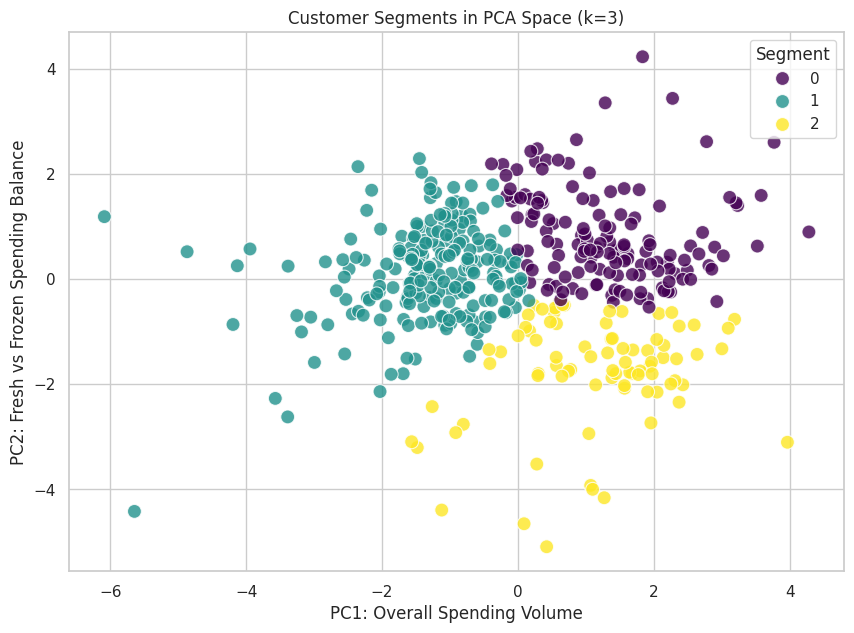

In [ ]:
# KMeans
best_model = KMeans(n_clusters=3, random_state=42, n_init='auto')
final_labels = best_model.fit_predict(X_pca)

plt.figure(figsize=(10, 7))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=final_labels, palette='viridis', s=100, alpha=0.8)
plt.title('Customer Segments in PCA Space (k=3)')
plt.xlabel('PC1: Overall Spending Volume')
plt.ylabel('PC2: Fresh vs Frozen Spending Balance')
plt.legend(title='Segment')
plt.show()

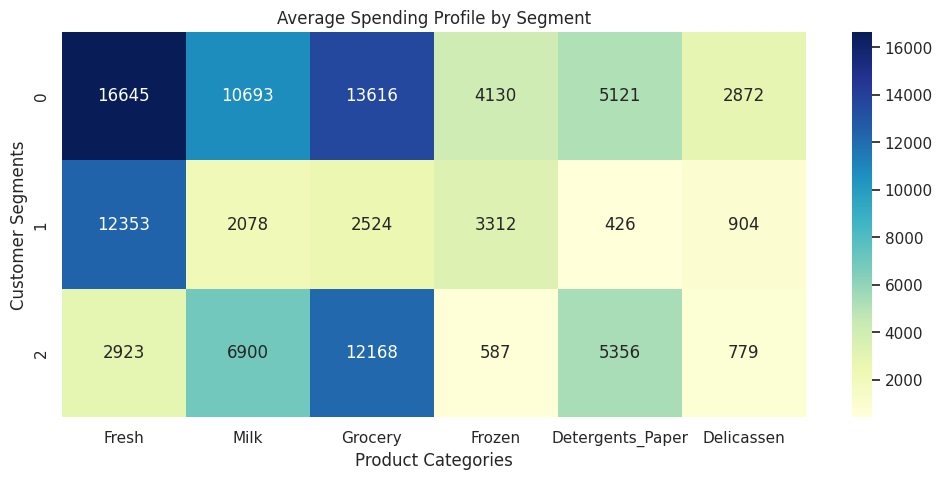

Segment Profiles (Averages):


,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
Segment,,,,,,
0,16645.486111,10693.326389,13615.645833,4129.930556,5121.111111,2871.902778
1,12352.757009,2078.042056,2523.813084,3312.252336,426.476636,904.084112
2,2923.060976,6900.207317,12168.451220,586.804878,5355.500000,779.451220


In [ ]:
# Segment profilleri
data['Segment'] = final_labels
segment_analysis = data.groupby('Segment')[numerical_features].mean()

plt.figure(figsize=(12, 5))
sns.heatmap(segment_analysis, annot=True, fmt='.0f', cmap='YlGnBu')
plt.title('Average Spending Profile by Segment')
plt.xlabel('Product Categories')
plt.ylabel('Customer Segments')
plt.show()

print("Segment Profiles (Averages):")
display(segment_analysis)